In [3]:
import pandas as pd
path="/content/Atlantic_United_Kingdom.csv"
df=pd.read_csv(path)
df.head()

,date,position,song,artist,popularity,duration_ms,album_type,total_tracks,is_explicit,album_cover_url
0,18-05-2024,1,Tattoo,Loreen,89,183374,single,1,False,https://i.scdn.co/image/ab67616d0000b2732b0ba8...
1,18-05-2024,2,Daylight,David Kushner,96,212953,single,1,False,https://i.scdn.co/image/ab67616d0000b27395ca6a...
2,18-05-2024,3,Cha Cha Cha,Käärijä,86,175161,single,1,False,https://i.scdn.co/image/ab67616d0000b273e9973a...
3,18-05-2024,4,Miracle (with Ellie Goulding),Calvin Harris & Ellie Goulding,91,186496,single,1,False,https://i.scdn.co/image/ab67616d0000b273c58e22...
4,18-05-2024,5,Queen of Kings,Alessandra,85,147979,single,1,False,https://i.scdn.co/image/ab67616d0000b2732c9eea...


In [4]:
df.info()
df.describe()
# Check missing values
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 27800 entries, 0 to 27799
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   date             27800 non-null  object
 1   position         27800 non-null  int64 
 2   song             27800 non-null  object
 3   artist           27800 non-null  object
 4   popularity       27800 non-null  int64 
 5   duration_ms      27800 non-null  int64 
 6   album_type       27800 non-null  object
 7   total_tracks     27800 non-null  int64 
 8   is_explicit      27800 non-null  bool  
 9   album_cover_url  27800 non-null  object
dtypes: bool(1), int64(4), object(5)
memory usage: 1.9+ MB


,0
date,0
position,0
song,0
artist,0
popularity,0
duration_ms,0
album_type,0
total_tracks,0
is_explicit,0
album_cover_url,0


In [11]:
#Data cleaning
df['popularity'] = pd.to_numeric(df['popularity'], errors='coerce')
df.head()



,date,position,song,artist,popularity,duration_ms,album_type,total_tracks,is_explicit,album_cover_url
0,18-05-2024,1,Tattoo,Loreen,89,183374,single,1,False,https://i.scdn.co/image/ab67616d0000b2732b0ba8...
1,18-05-2024,2,Daylight,David Kushner,96,212953,single,1,False,https://i.scdn.co/image/ab67616d0000b27395ca6a...
2,18-05-2024,3,Cha Cha Cha,Käärijä,86,175161,single,1,False,https://i.scdn.co/image/ab67616d0000b273e9973a...
3,18-05-2024,4,Miracle (with Ellie Goulding),Calvin Harris & Ellie Goulding,91,186496,single,1,False,https://i.scdn.co/image/ab67616d0000b273c58e22...
4,18-05-2024,5,Queen of Kings,Alessandra,85,147979,single,1,False,https://i.scdn.co/image/ab67616d0000b2732c9eea...


In [8]:
artist_count = df['artist'].value_counts().head(10)
artist_count

,count
artist,
Taylor Swift,2092
Sabrina Carpenter,965
Billie Eilish,819
Olivia Rodrigo,643
Chappell Roan,634
Benson Boone,537
The Killers,512
Dua Lipa,485
Drake,454


In [12]:
#Artist Dominance
df.groupby('artist')['popularity'].mean().sort_values(ascending=False).head(10)

,popularity
artist,
Jung Kook & Latto,99.000000
FIFTY FIFTY,98.128205
Lady Gaga & Bruno Mars,96.805825
The Weeknd & JENNIE & Lily-Rose Depp,96.720930
Mitski,96.073684
David Kushner,95.829787
ROSÉ & Bruno Mars,94.717949
Jack Harlow,94.656805
Djo,94.433526


In [16]:
#Collaboration Impact
df.groupby('album_type')['popularity'].mean()

,popularity
album_type,
album,86.282002
compilation,77.833333
single,87.617996


In [15]:
#Explicit Impact
df.groupby('is_explicit')['popularity'].mean()

,popularity
is_explicit,
False,86.830844
True,86.701550


In [18]:
#International Artist vs Unitied Kingdom
uk_artists = [
    'Ed Sheeran',
    'Harry Styles',
    'Dua Lipa',
    'Stormzy',
    'Central Cee',
    'Lewis Capaldi',
    'Sam Smith',
    'Dave',
    'Little Mix'
]
df['origin'] = df['artist'].apply(
    lambda x: 'UK' if any(artist in str(x) for artist in uk_artists) else 'International'
)
origin_perf = df.groupby('origin')['popularity'].mean()
origin_perf


,popularity
origin,
International,86.676133
UK,88.459490


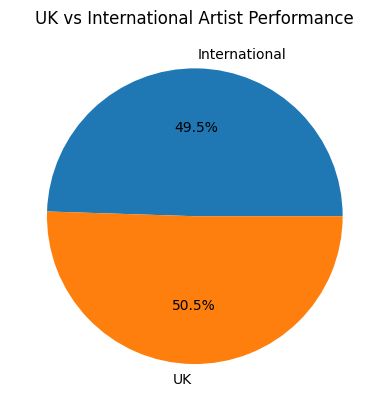

In [19]:
#Visualisation
import matplotlib.pyplot as plt

origin_perf.plot(kind='pie', autopct='%1.1f%%')
plt.title("UK vs International Artist Performance")
plt.ylabel('')
plt.show()

In [20]:
from google.colab import drive
drive.mount("/content/drive")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
